# Model 1: Randomforest

#### Import necessary dependencies

In [1]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split

### 1. Define dataset paths

In [2]:
# Define file path
dataset_path = r"D:\Universität\Master\Semester2\RealWorld_ML_Problems\Data\output\bookmeas\bookmeas_e_2025-03-19_to_2025-03-28_cleaned_spearman.parquet"

### 2. Load datasets via DuckDB

In [3]:
con = duckdb.connect()
df = con.execute(f"SELECT * FROM '{dataset_path}'").fetchdf()
con.close()

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (1156389, 275)
   booking_id_00  booking_id_01  booking_id_02  booking_id_03  booking_id_04  \
0      -0.144847      -0.899209       0.017111      -0.877257      -1.176731   
1      -0.144847      -0.899209       0.017111      -0.877257      -1.176731   
2      -0.144847      -0.899209       0.017111      -0.877257      -1.176731   
3      -0.144847      -0.899209       0.017111      -0.877257      -1.176731   
4      -0.144847      -0.899209       0.017111      -0.877257      -1.176731   

   booking_id_05  booking_id_06  booking_id_07  booking_id_08  booking_id_09  \
0      -0.189034      -0.596354       -0.67936       0.713508       0.353852   
1      -0.189034      -0.596354       -0.67936       0.713508       0.353852   
2      -0.189034      -0.596354       -0.67936       0.713508       0.353852   
3      -0.189034      -0.596354       -0.67936       0.713508       0.353852   
4      -0.189034      -0.596354       -0.67936       0.713508       0.353852   

   ...  

### 3. Prepare features X and target y

In [4]:
target = 'target'

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")

X = df.drop(columns=[target])
y = df[target]

### 4. Train-test split (85% train, 15% test)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (982930, 274), Test shape: (173459, 274)


###  5. Train Random Forest classifier

In [6]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced', max_depth=15, min_samples_leaf=2)

print("Training RandomForest model...")
clf.fit(X_train, y_train)

Training RandomForest model...


,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6. Evaluate on test set

In [7]:
y_test_pred = clf.predict(X_test)
print("Test classification report:")
print(classification_report(y_test, y_test_pred))

Test classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    173400
         1.0       1.00      0.88      0.93        56
         2.0       0.00      0.00      0.00         3

    accuracy                           1.00    173459
   macro avg       0.67      0.62      0.64    173459
weighted avg       1.00      1.00      1.00    173459



D:\Universität\Master\Semester2\RealWorld_ML_Problems\Code\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Universität\Master\Semester2\RealWorld_ML_Problems\Code\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Universität\Master\Semester2\RealWorld_ML_Problems\Code\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

### 7. Metrics & Confusion Matrix

Accuracy:  0.9999
Precision: 0.9999
Recall:    0.9999
F1 Score:  0.9999


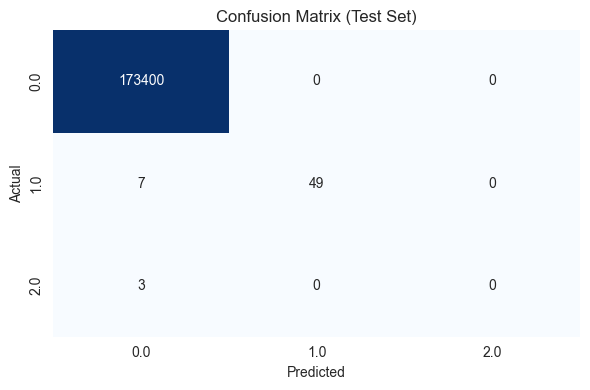

In [8]:
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

class_labels = sorted(y_test.unique())

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()